In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import glob

# =========================
# LOAD DATA
# =========================
price_files = sorted(glob.glob("../../../data_capsule/ROUND_3/prices_round_3_day_*.csv"))
prices = pd.concat([pd.read_csv(f, sep=';') for f in price_files], ignore_index=True)


In [5]:
hydro = prices[prices["product"] == "HYDROGEL_PACK"].copy()
vev = prices[prices["product"] == "VELVETFRUIT_EXTRACT"].copy()

for df in [hydro, vev]:
    df["mid"] = (df["bid_price_1"] + df["ask_price_1"]) / 2
    df = df.sort_values(["day", "timestamp"])

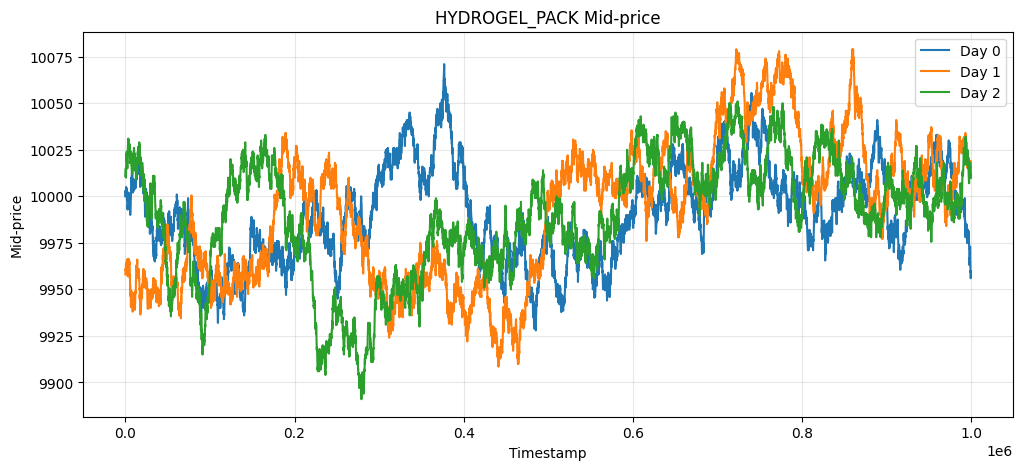

In [6]:
plt.figure(figsize=(12,5))

for day, g in hydro.groupby("day"):
    plt.plot(g["timestamp"], g["mid"], label=f"Day {day}")

plt.title("HYDROGEL_PACK Mid-price")
plt.xlabel("Timestamp")
plt.ylabel("Mid-price")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

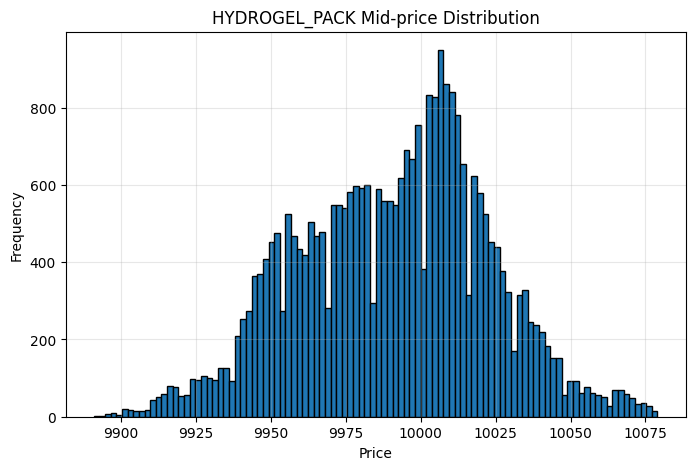

In [7]:
plt.figure(figsize=(8,5))
plt.hist(hydro["mid"].dropna(), bins=100, edgecolor="black")

plt.title("HYDROGEL_PACK Mid-price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

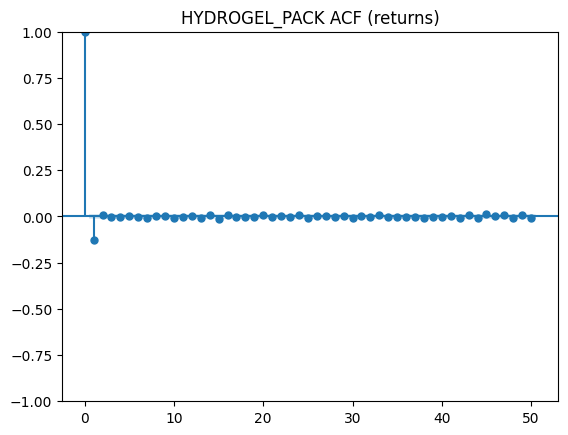

In [8]:
from statsmodels.graphics.tsaplots import plot_acf
import numpy as np

hydro["log_mid"] = np.log(hydro["mid"].replace(0, np.nan))
hydro["ret"] = hydro.groupby("day")["log_mid"].diff()

rets = hydro["ret"].dropna()

plot_acf(rets, lags=50)
plt.title("HYDROGEL_PACK ACF (returns)")
plt.show()

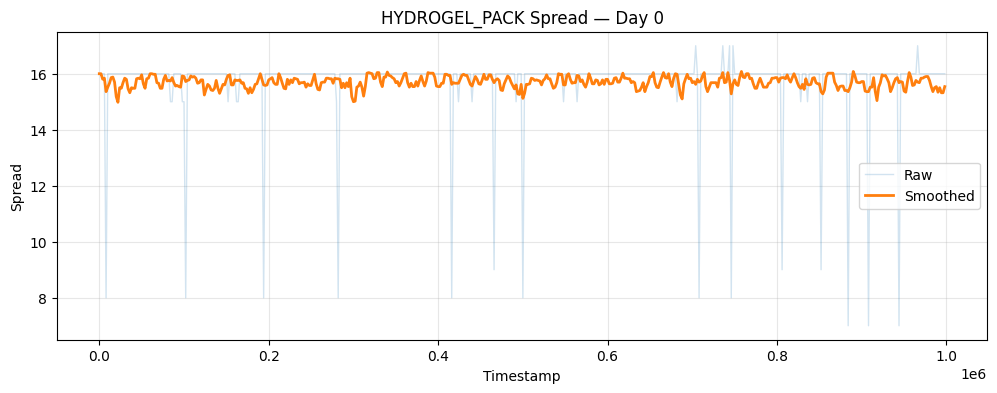

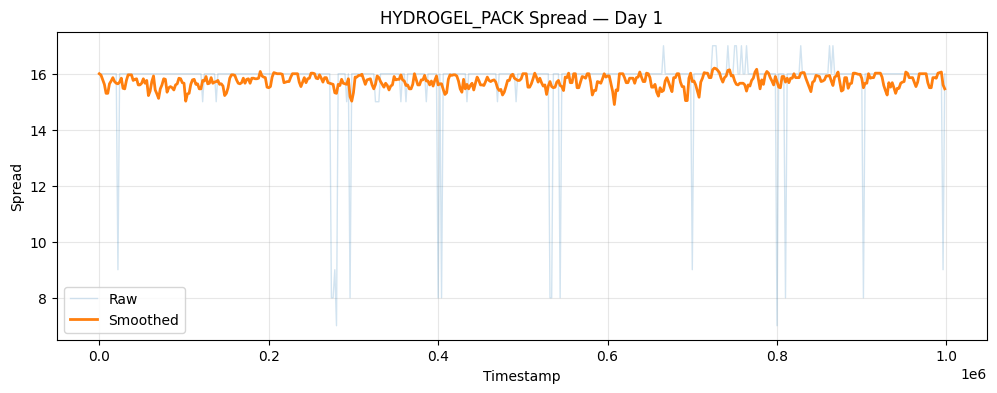

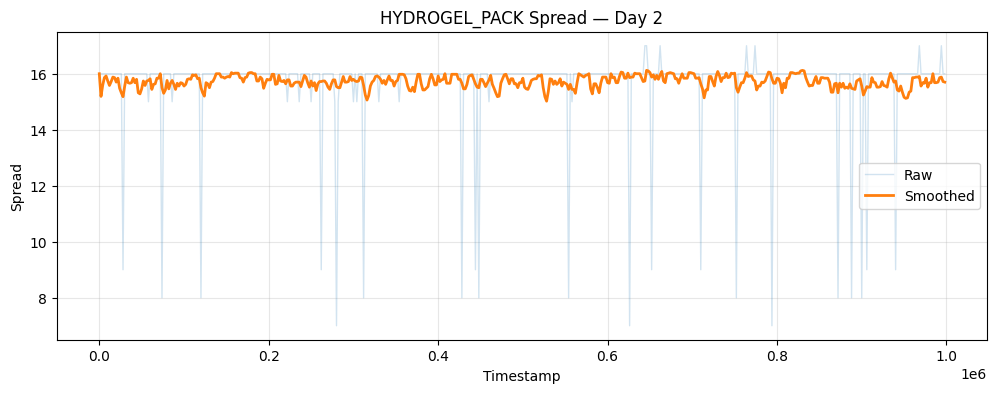

In [9]:
# Compute spread
hydro["spread"] = hydro["ask_price_1"] - hydro["bid_price_1"]

# Smooth (reduces microstructure noise)
hydro["spread_smooth"] = hydro.groupby("day")["spread"].transform(
    lambda x: x.rolling(50, min_periods=1).mean()
)

# Plot (clean + readable)
for day, g in hydro.groupby("day"):
    
    # Downsample to avoid overplotting
    g_plot = g.iloc[::20]
    
    plt.figure(figsize=(12,4))
    
    # Raw (very light)
    plt.plot(
        g_plot["timestamp"],
        g_plot["spread"],
        alpha=0.2,
        linewidth=1,
        label="Raw"
    )
    
    # Smoothed (main signal)
    plt.plot(
        g_plot["timestamp"],
        g_plot["spread_smooth"],
        linewidth=2,
        label="Smoothed"
    )
    
    plt.title(f"HYDROGEL_PACK Spread — Day {day}")
    plt.xlabel("Timestamp")
    plt.ylabel("Spread")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()

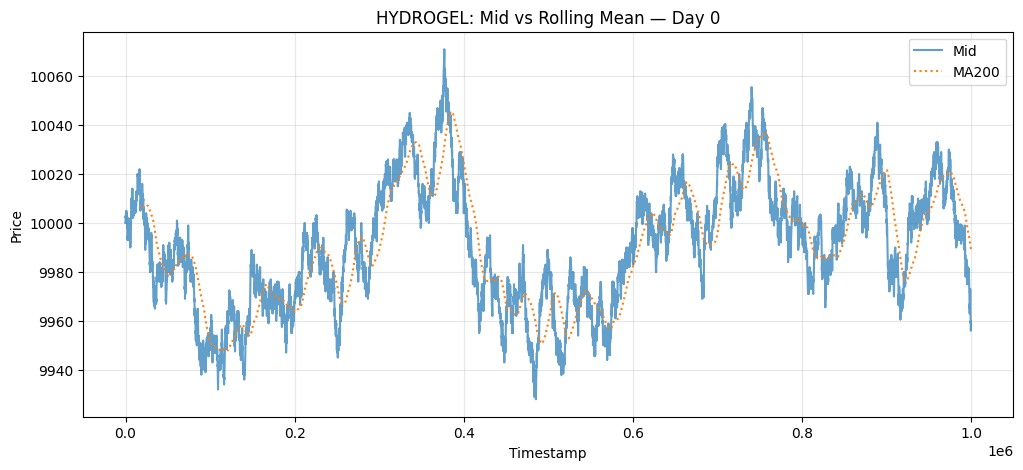

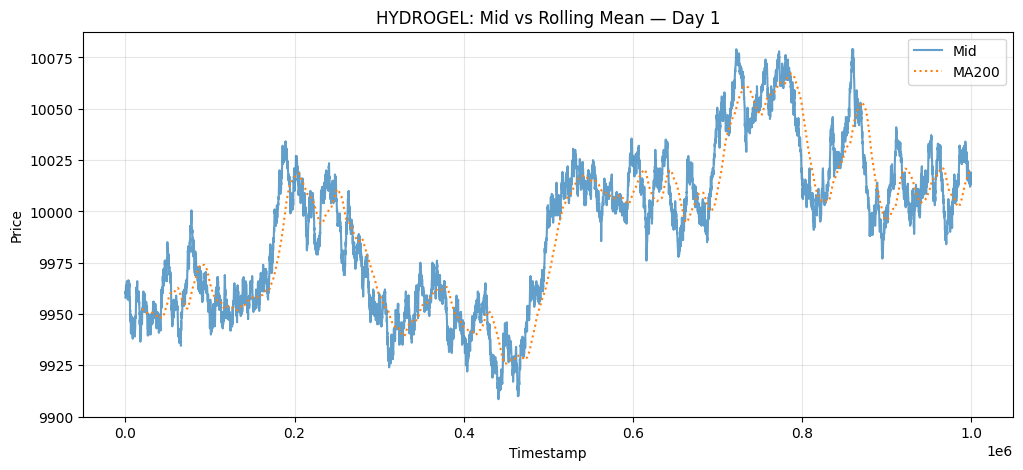

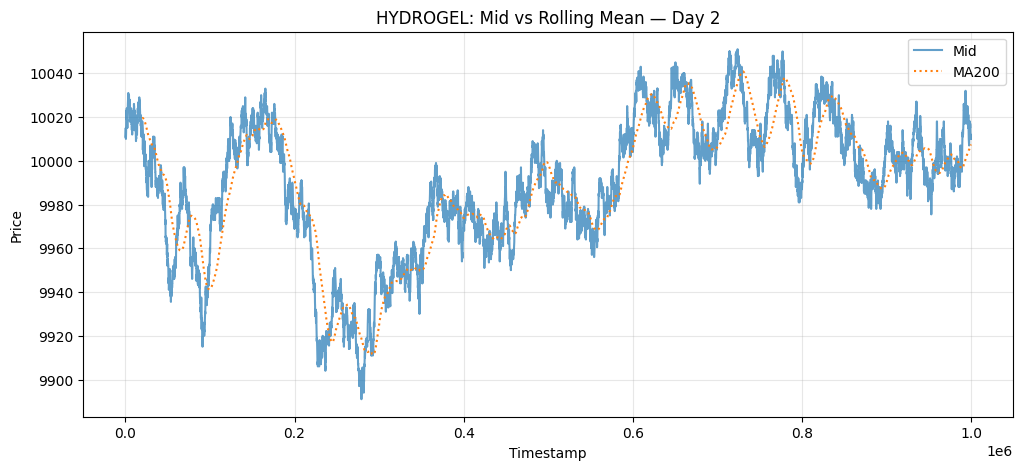

In [15]:
hydro = prices[prices["product"] == "HYDROGEL_PACK"].copy()
hydro["mid"] = (hydro["bid_price_1"] + hydro["ask_price_1"]) / 2
hydro = hydro.sort_values(["day","timestamp"])

# Rolling means
# hydro["roll_50"] = hydro.groupby("day")["mid"].transform(lambda x: x.rolling(50).mean())
hydro["roll_200"] = hydro.groupby("day")["mid"].transform(lambda x: x.rolling(200).mean())

# Plot each day separately
for day, g in hydro.groupby("day"):
    plt.figure(figsize=(12,5))
    
    plt.plot(g["timestamp"], g["mid"], label="Mid", alpha=0.7)
    # plt.plot(g["timestamp"], g["roll_50"], linestyle="--", label="MA50")
    plt.plot(g["timestamp"], g["roll_200"], linestyle=":", label="MA200")
    
    plt.title(f"HYDROGEL: Mid vs Rolling Mean — Day {day}")
    plt.xlabel("Timestamp")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(alpha=0.3)
    
    plt.show()

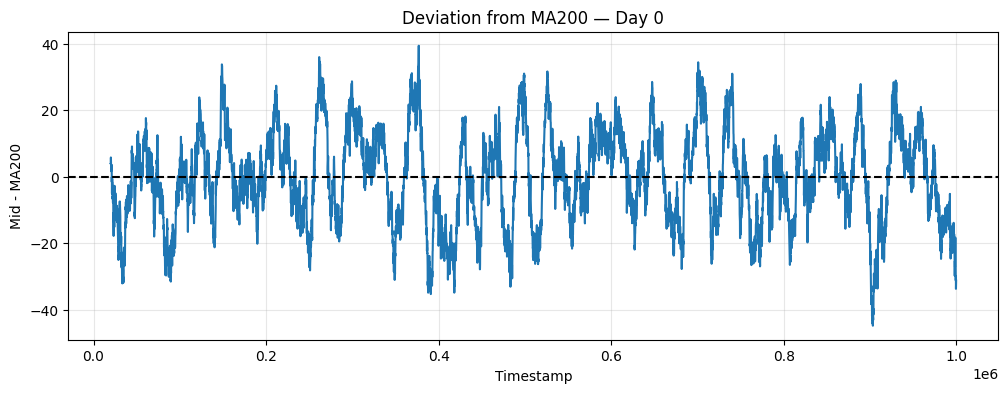

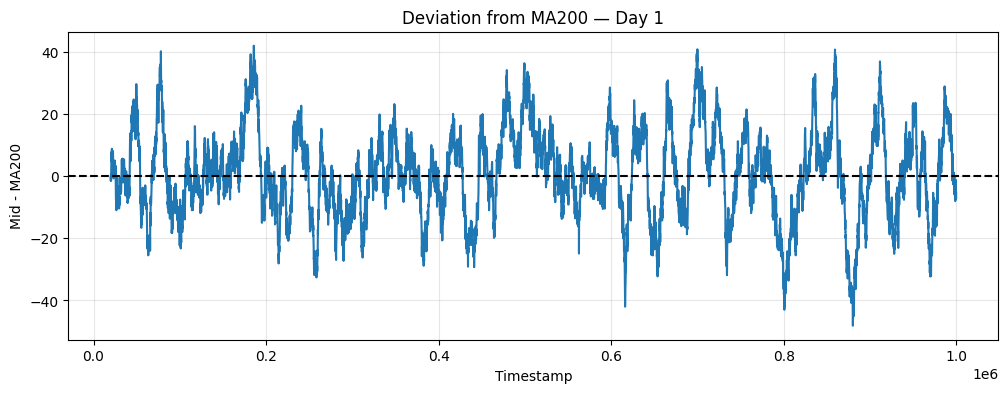

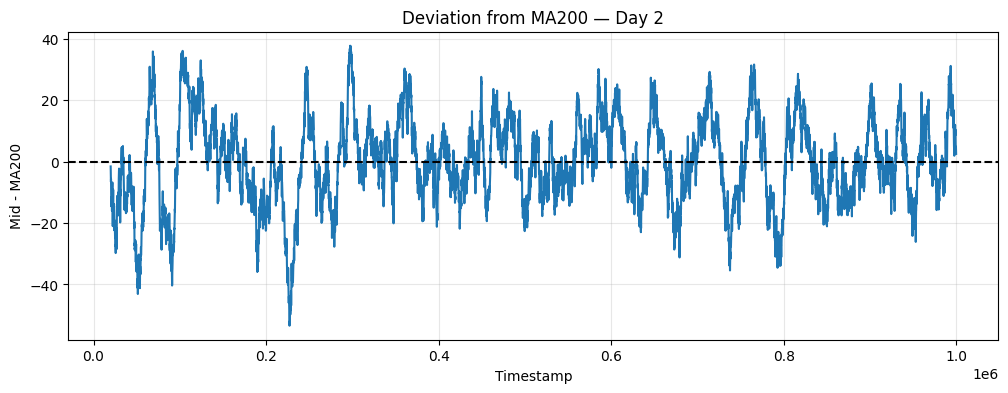

In [16]:
hydro["dev"] = hydro["mid"] - hydro["roll_200"]

for day, g in hydro.groupby("day"):
    plt.figure(figsize=(12,4))
    
    plt.plot(g["timestamp"], g["dev"])
    plt.axhline(0, linestyle="--", color="black")
    
    plt.title(f"Deviation from MA200 — Day {day}")
    plt.xlabel("Timestamp")
    plt.ylabel("Mid - MA200")
    plt.grid(alpha=0.3)
    
    plt.show()

### Cross Product Graphs

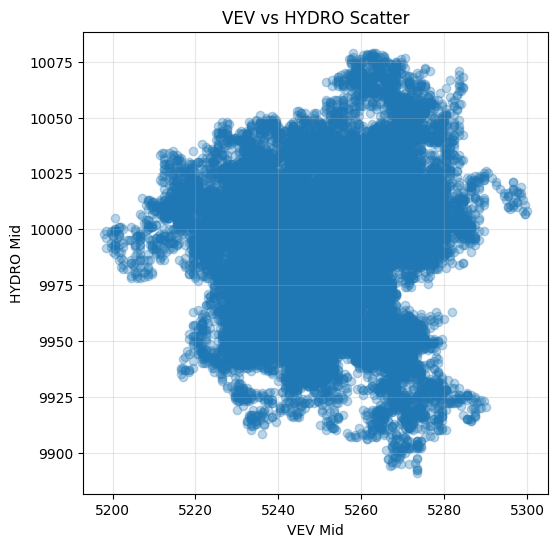

Correlation: 0.09672716923699691


In [12]:
merged = hydro.merge(
    vev[["day","timestamp","mid"]],
    on=["day","timestamp"],
    suffixes=("_hydro","_vev")
)

# Scatter
plt.figure(figsize=(6,6))
plt.scatter(merged["mid_vev"], merged["mid_hydro"], alpha=0.3)

plt.xlabel("VEV Mid")
plt.ylabel("HYDRO Mid")
plt.title("VEV vs HYDRO Scatter")
plt.grid(alpha=0.3)
plt.show()

# Correlation
corr = merged["mid_vev"].corr(merged["mid_hydro"])
print("Correlation:", corr)

In [13]:
# Recreate df properly (OPTIONS dataset)
options = prices[prices["product"].str.contains("VEV_")].copy()

# Extract strike
options["strike"] = options["product"].str.split("_").str[1].astype(int)

# Mid price
options["option_mid"] = (options["bid_price_1"] + options["ask_price_1"]) / 2

df = options.copy()

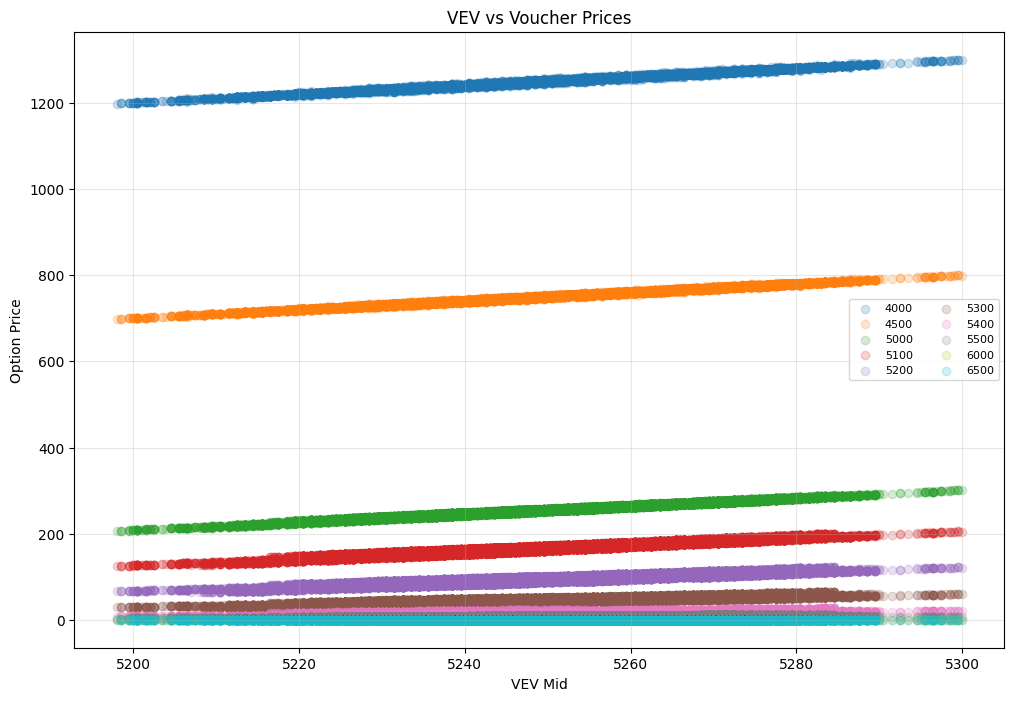

In [14]:
plt.figure(figsize=(12,8))

for strike, g in df.groupby("strike"):
    merged = g.merge(
        vev[["day","timestamp","mid"]],
        on=["day","timestamp"],
        suffixes=("_opt","_vev")
    )
    
    plt.scatter(
        merged["mid"],          # VEV mid
        merged["option_mid"],   # option price
        alpha=0.2,
        label=str(strike)
    )

plt.xlabel("VEV Mid")
plt.ylabel("Option Price")
plt.title("VEV vs Voucher Prices")
plt.legend(ncol=2, fontsize=8)
plt.grid(alpha=0.3)
plt.show()